# Phase 5: Clustering

This notebook discovers candidate molecular subtypes from the reduced feature space.

Why this stage matters:
- clustering is the core unsupervised learning step in the project,
- the project does not assume subtype labels in advance,
- cluster quality metrics help choose a reasonable number of groups,
- and comparing K-Means with hierarchical clustering gives extra context about solution stability.

The notebook uses PCA output for clustering and UMAP output for visualization so the analysis stays both computationally efficient and easy to interpret.

---

## Cell 1: Import clustering tools and load saved reduced features

This cell imports the clustering functions from `src/clustering.py` and the general-purpose libraries used in the rest of the notebook.

What this setup enables:
- loading `X_pca` for the actual clustering calculations,
- loading `X_umap` for plotting only,
- importing reusable helper functions such as `find_optimal_k`, `run_kmeans`, and `plot_clusters_umap`,
- and keeping the notebook connected to the same project code used elsewhere.

Separating reusable logic into the source module keeps the notebook easier to read and maintain.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sys
import os

# Add project root so Python can find src/clustering.py
sys.path.append('..')

# Import ALL functions from src/clustering.py
from src.clustering import (
    load_config,
    find_optimal_k,
    plot_k_selection,
    run_kmeans,
    run_hierarchical,
    evaluate_clusters,
    plot_clusters_umap,
    run_clustering
)

plt.rcParams['figure.dpi'] = 120

print('All imports successful!')


All imports successful!


## Cell 2: Load and inspect clustering configuration

This cell reads `config.yaml` so the notebook can use the same cluster-search settings as the pipeline.

The printed values matter because they control:
- the range of `K` values tested,
- how many K-Means initializations are used,
- and the random seed that helps keep results reproducible.

It is a good practice to inspect these values before running expensive clustering loops so you know exactly what experiment is being performed.

In [2]:
config = load_config('../config.yaml')

print('Config loaded from config.yaml!')
print(f"  k_range_min:  {config['clustering']['k_range_min']}")
print(f"  k_range_max:  {config['clustering']['k_range_max']}")
print(f"  n_init:       {config['clustering']['n_init']}")
print(f"  random_state: {config['clustering']['random_state']}")

# Load X_pca and X_umap saved at end of Phase 4
X_pca  = np.load('../results/X_pca.npy')
X_umap = np.load('../results/X_umap.npy')

print(f'\nPhase 4 results loaded!')
print(f'  X_pca  shape: {X_pca.shape}  → clustering runs ON THIS')
print(f'  X_umap shape: {X_umap.shape} → used FOR plotting only')

Config loaded from config.yaml!
  k_range_min:  2
  k_range_max:  9
  n_init:       10
  random_state: 42

Phase 4 results loaded!
  X_pca  shape: (23686, 50)  → clustering runs ON THIS
  X_umap shape: (23686, 2) → used FOR plotting only


## Cell 3: Search for the best number of clusters

This cell calls `find_optimal_k(...)`, which runs K-Means repeatedly across a range of `K` values.

For each candidate `K`, the function computes:
- inertia, which supports elbow-curve interpretation,
- silhouette score, which measures separation and cohesion,
- Davies-Bouldin score, where lower values are better,
- and Calinski-Harabasz score, where higher values are better.

The goal is not to treat any single metric as absolute truth, but to build evidence for a sensible cluster count.

In [3]:
# find_optimal_k() is defined in src/clustering.py
# It runs KMeans for each K and calculates:
#   - inertia (elbow method)
#   - silhouette score
#   - davies bouldin score
#   - calinski harabasz score

best_k, scores = find_optimal_k(X_pca, config)

print(f'\nBest K = {best_k}')
print(f'Scores dict keys: {list(scores.keys())}')

Finding optimal K (testing K=2 to K=9)...
  Testing K=2... 

c:\Users\DELL\miniconda3\envs\genomics_pipeline\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Silhouette=0.608, Davies-Bouldin=0.885
  Testing K=3... Silhouette=0.539, Davies-Bouldin=1.018
  Testing K=4... Silhouette=0.496, Davies-Bouldin=1.160
  Testing K=5... Silhouette=0.491, Davies-Bouldin=1.122
  Testing K=6... Silhouette=0.463, Davies-Bouldin=1.205
  Testing K=7... Silhouette=0.450, Davies-Bouldin=1.201
  Testing K=8... Silhouette=0.423, Davies-Bouldin=1.307
  Testing K=9... Silhouette=0.426, Davies-Bouldin=1.380

✅ Best K = 2 (highest silhouette score: 0.608)

Best K = 2
Scores dict keys: ['k_range', 'inertia', 'silhouette', 'davies_bouldin', 'calinski']


## Cell 4: Visualize the cluster-selection metrics

This cell plots the diagnostics returned by the K search.

How to read these charts:
- the elbow plot shows diminishing returns in compactness as `K` increases,
- the silhouette plot highlights which `K` creates the cleanest separation,
- and the Davies-Bouldin plot helps flag cluster solutions that are too overlapping.

Together, these figures make the cluster-count choice more transparent than picking a value arbitrarily.

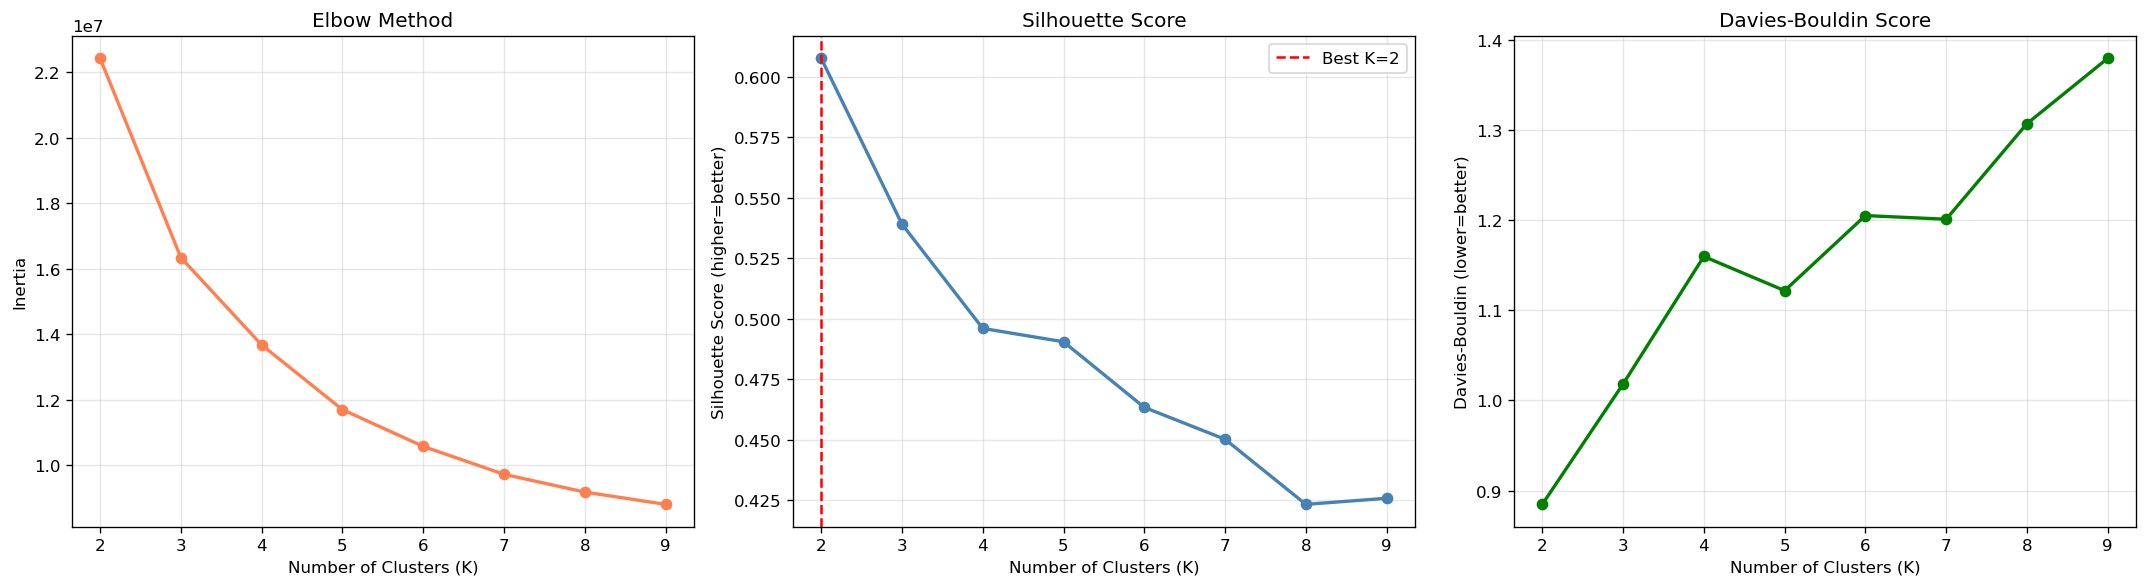

K selection plots saved!

How to read the 3 plots:
  Plot 1 (Elbow):          look for where the curve bends
  Plot 2 (Silhouette):     look for the PEAK  (red dot = best K)
  Plot 3 (Davies-Bouldin): look for the VALLEY (red dot = best K)

  All 3 should agree on K = 2


In [4]:
plot_k_selection(scores, save_dir='../results/')

print('\nHow to read the 3 plots:')
print('  Plot 1 (Elbow):          look for where the curve bends')
print('  Plot 2 (Silhouette):     look for the PEAK  (red dot = best K)')
print('  Plot 3 (Davies-Bouldin): look for the VALLEY (red dot = best K)')
print(f'\n  All 3 should agree on K = {best_k}')

## Cell 5: Fit the final K-Means model

This cell trains the main clustering model using the selected `best_k`.

What the output means:
- `kmeans_labels` assigns every cell to one discovered subtype,
- the fitted `kmeans` object stores centroids and model settings,
- and the label distribution helps reveal whether any cluster is extremely small or overly dominant.

These labels are central to the rest of the project because they become the target values for interpretation and later classifier training.

In [5]:
kmeans_labels, kmeans = run_kmeans(X_pca, best_k, config)

print(f'\nkmeans_labels sample: {kmeans_labels[:20]}')
print(f'Total labels: {len(kmeans_labels)} (one per cell)')
print(f'Unique values: {sorted(set(kmeans_labels))} (cluster IDs)')

Running K-Means with K=2...
  Cluster sizes:
    Subtype 0: 4476 cells (18.9%)
    Subtype 1: 19210 cells (81.1%)

kmeans_labels sample: [1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0]
Total labels: 23686 (one per cell)
Unique values: [0, 1] (cluster IDs)


## Cell 6: Fit the hierarchical clustering comparison model

This cell runs agglomerative clustering with the same number of clusters.

Why include a comparison model:
- different clustering algorithms can group the same data differently,
- comparing them helps assess whether the discovered structure is robust,
- and hierarchical clustering gives a second unsupervised view that is not centroid-based like K-Means.

The point here is not necessarily to replace K-Means, but to add analytical context.

In [6]:
hier_labels = run_hierarchical(X_pca, best_k)

print(f'\nhier_labels sample: {hier_labels[:20]}')
print(f'Total labels: {len(hier_labels)} (one per cell)')
print(f'Unique values: {sorted(set(hier_labels))} (cluster IDs)')

Running Hierarchical clustering with K=2...
  Hierarchical clustering complete ✓

hier_labels sample: [1 0 0 1 0 1 1 0 1 1 1 0 0 1 1 1 1 1 1 0]
Total labels: 23686 (one per cell)
Unique values: [0, 1] (cluster IDs)


## Cell 7: Evaluate both clustering solutions

This cell applies the same quality metrics to the final K-Means and hierarchical labels.

Why this is useful:
- it shows whether the selected K-Means solution is competitive with the comparison method,
- it helps quantify separation rather than relying only on visual intuition,
- and it creates a record of model quality that can be reused in reports or documentation.

This evaluation step also helps justify why one labeling scheme is carried forward into later phases.

In [11]:
print('Evaluating K-Means...')
km_scores = evaluate_clusters(X_pca, kmeans_labels, 'K-Means')

print('\nEvaluating Hierarchical...')
hier_scores = evaluate_clusters(X_pca, hier_labels, 'Hierarchical')

# Side by side comparison
print('\n' + '=' * 55)
print(f"{'Metric':<25} {'K-Means':>12} {'Hierarchical':>14}")
print('-' * 55)
print(f"{'Silhouette (higher=better)':<25} {km_scores['silhouette']:>12.4f} {hier_scores['silhouette']:>14.4f}")
print(f"{'Davies-Bouldin (lower=better)':<25} {km_scores['davies_bouldin']:>12.4f} {hier_scores['davies_bouldin']:>14.4f}")
print(f"{'Calinski (higher=better)':<25} {km_scores['calinski']:>12.1f} {hier_scores['calinski']:>14.1f}")
print('=' * 55)

# Count wins
km_wins = sum([
    km_scores['silhouette']    > hier_scores['silhouette'],
    km_scores['davies_bouldin']< hier_scores['davies_bouldin'],
    km_scores['calinski']      > hier_scores['calinski']
])
winner = 'K-Means' if km_wins >= 2 else 'Hierarchical'
print(f'\nWinner: {winner}')
print(f'Using {winner} labels going forward.')
final_labels = kmeans_labels if winner == 'K-Means' else hier_labels


Evaluating K-Means...

K-Means Evaluation:
  Silhouette Score:        0.608  (↑ higher better, max=1)
  Davies-Bouldin Score:    0.885  (↓ lower better, min=0)
  Calinski-Harabasz Score: 22157.6 (↑ higher better)

Evaluating Hierarchical...

Hierarchical Evaluation:
  Silhouette Score:        0.553  (↑ higher better, max=1)
  Davies-Bouldin Score:    0.935  (↓ lower better, min=0)
  Calinski-Harabasz Score: 19537.9 (↑ higher better)

Metric                         K-Means   Hierarchical
-------------------------------------------------------
Silhouette (higher=better)       0.6076         0.5530
Davies-Bouldin (lower=better)       0.8847         0.9351
Calinski (higher=better)       22157.6        19537.9

Winner: K-Means
Using K-Means labels going forward.


## Cell 8: Plot K-Means clusters on the UMAP embedding

This cell overlays the K-Means subtype labels on the 2D UMAP coordinates.

What to look for in the figure:
- whether clusters occupy clearly separated regions,
- whether there are diffuse boundaries between groups,
- whether any subtype appears fragmented into disconnected islands,
- and whether the cluster sizes look plausible.

This is one of the most intuitive project visuals because it connects numerical clustering to a human-readable map.

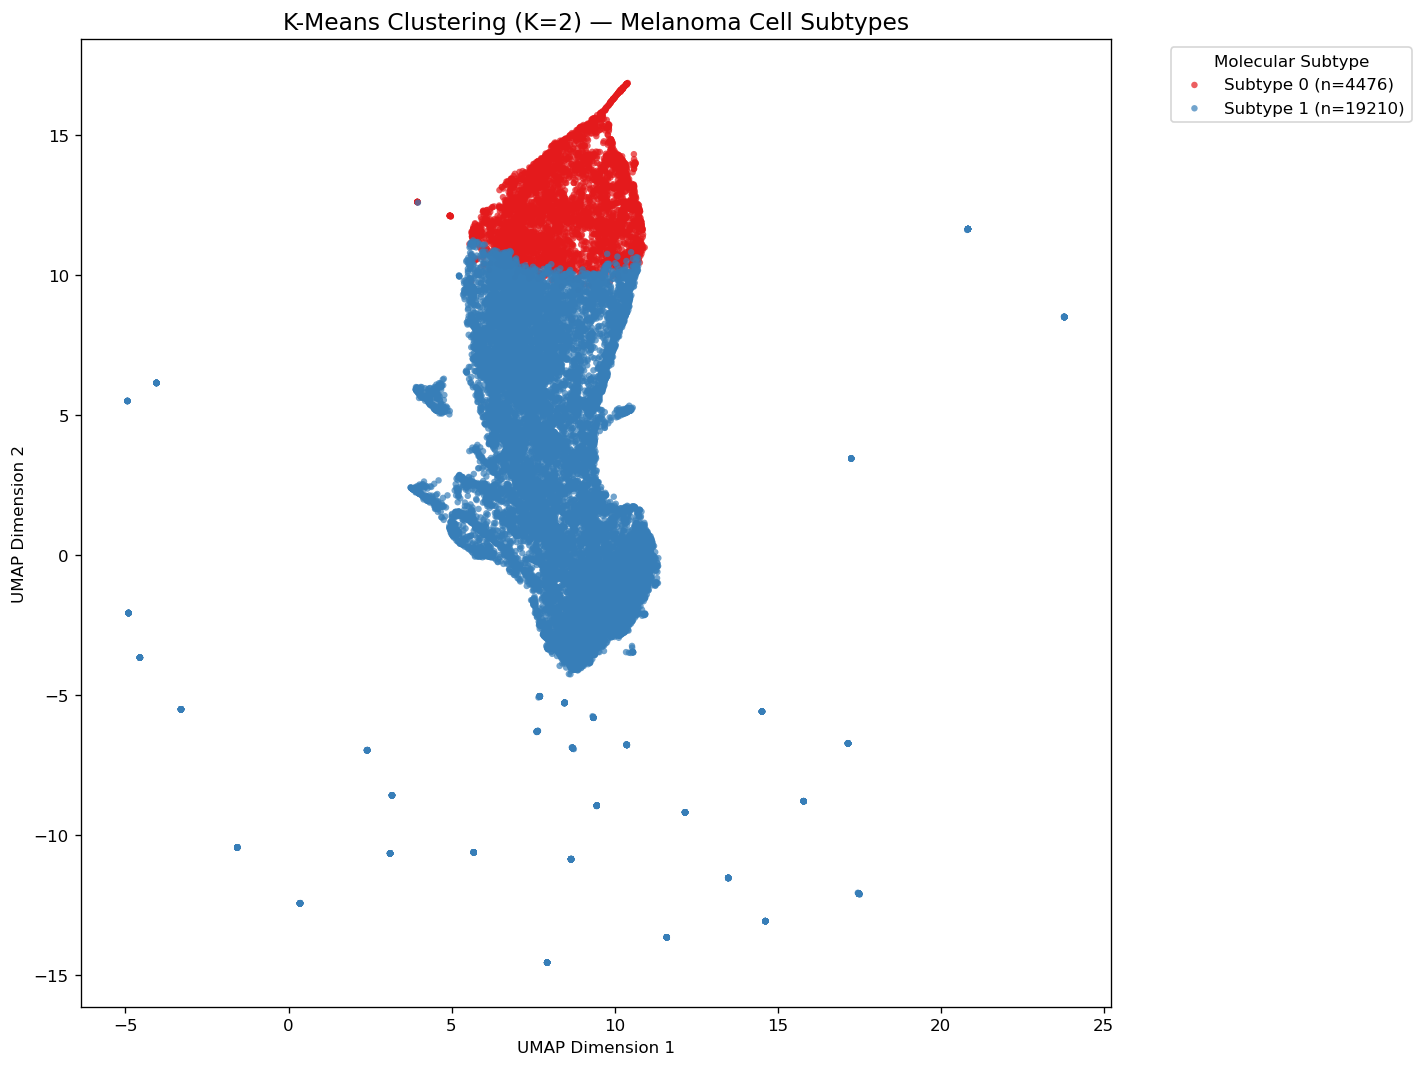

Plot saved: ../results/07_kmeans_clusters.png


In [12]:
plot_clusters_umap(
    X_umap,
    kmeans_labels,
    title=f'K-Means Clustering (K={best_k}) — Melanoma Cell Subtypes',
    save_path='../results/07_kmeans_clusters.png'
)

## Cell 9: Plot hierarchical clusters on the UMAP embedding

This cell repeats the same visualization approach for hierarchical clustering.

The comparison helps answer questions like:
- do both methods find similar high-level structure,
- are the same regions consistently grouped together,
- and does one method appear more stable or interpretable on the 2D map.

Side-by-side visual comparisons are especially helpful when metrics alone do not tell the whole story.

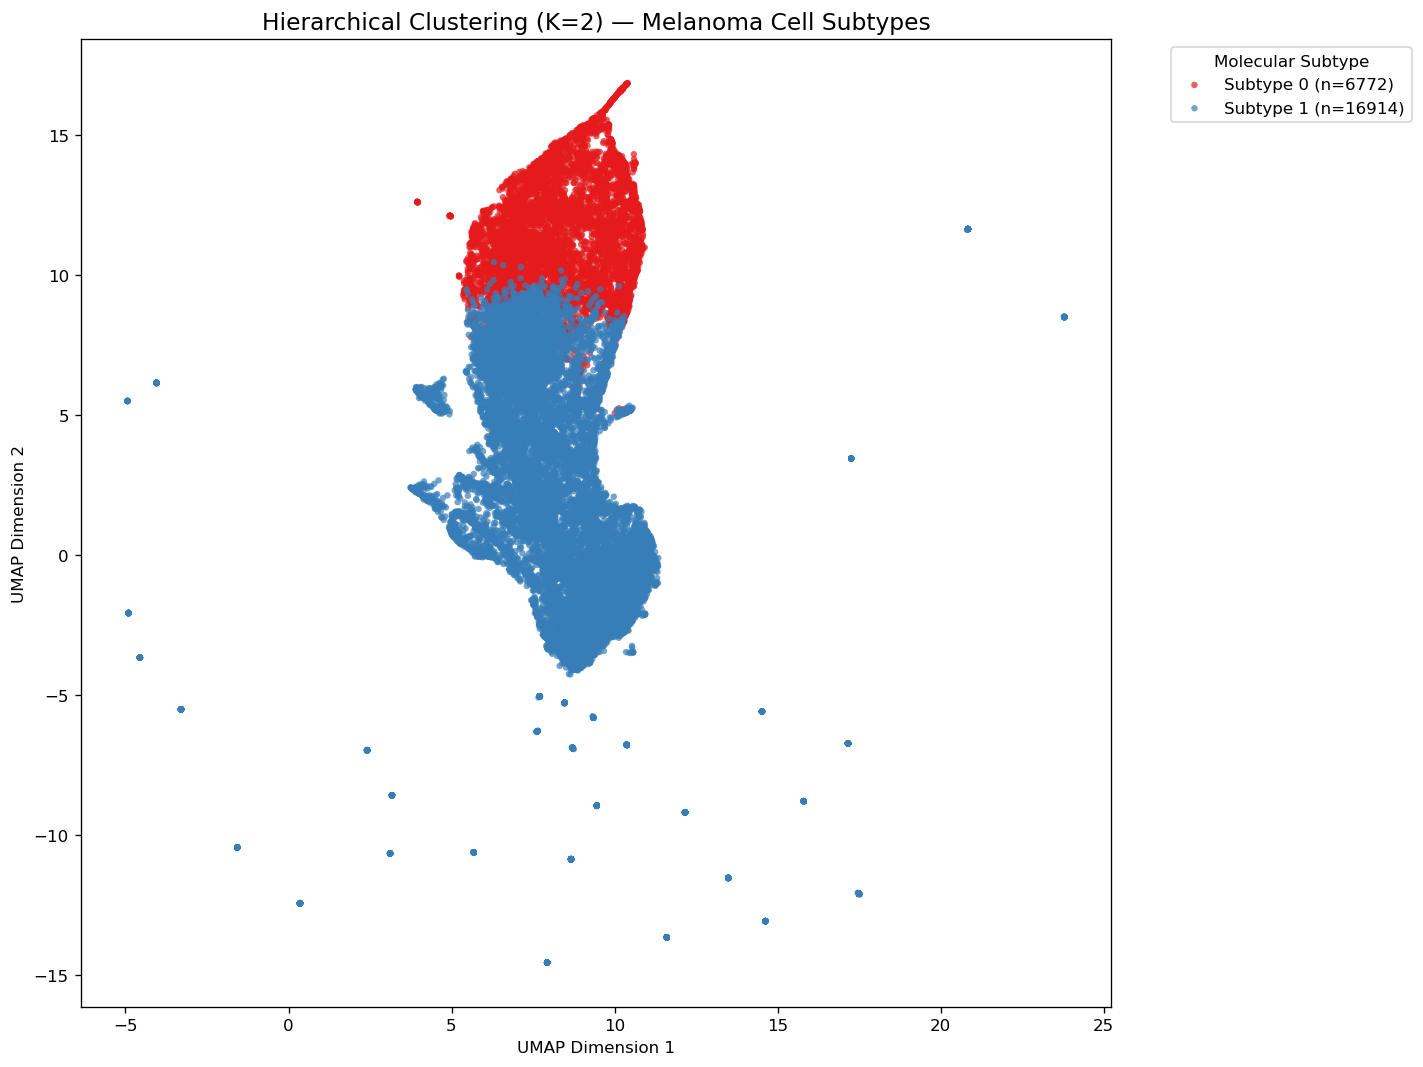

Plot saved: ../results/08_hierarchical_clusters.png


In [13]:
plot_clusters_umap(
    X_umap,
    hier_labels,
    title=f'Hierarchical Clustering (K={best_k}) — Melanoma Cell Subtypes',
    save_path='../results/08_hierarchical_clusters.png'
)

## Cell 10: Save labels, models, and summary outputs

This final cell writes the clustering artifacts needed by later notebooks and deployment code.

Typically this includes:
- label arrays for downstream interpretation,
- the fitted K-Means model for reuse,
- and tabular summaries that connect subtype assignments to cells and UMAP coordinates.

Saving these artifacts is what allows the biological interpretation and prediction stages to build directly on the discovered clusters without rerunning the full search.

In [14]:
os.makedirs('../results', exist_ok=True)
os.makedirs('../models',  exist_ok=True)

# Save label arrays (used by Phase 6)
np.save('../results/kmeans_labels.npy', kmeans_labels)
np.save('../results/hier_labels.npy',   hier_labels)
np.save('../results/final_labels.npy',  final_labels)

# Save trained K-Means model (used by API)
joblib.dump(kmeans, '../models/kmeans.pkl')

# Save full CSV with UMAP coords + labels (used by dashboard)
pd.DataFrame({
    'cell_index':     range(len(kmeans_labels)),
    'kmeans_subtype': kmeans_labels,
    'hier_subtype':   hier_labels,
    'final_subtype':  final_labels,
    'umap_x':         X_umap[:, 0],
    'umap_y':         X_umap[:, 1]
}).to_csv('../results/cluster_assignments.csv', index=False)

print('All results saved!')
print('\nFiles:')
print('  results/kmeans_labels.npy        used by Phase 6 interpreter')
print('  results/hier_labels.npy          used by Phase 6 interpreter')
print('  results/final_labels.npy         used by Phase 6 interpreter')
print('  results/cluster_assignments.csv  used by dashboard')
print('  models/kmeans.pkl                used by API predictor')

All results saved!

Files:
  results/kmeans_labels.npy        used by Phase 6 interpreter
  results/hier_labels.npy          used by Phase 6 interpreter
  results/final_labels.npy         used by Phase 6 interpreter
  results/cluster_assignments.csv  used by dashboard
  models/kmeans.pkl                used by API predictor
